## 1. IMPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import random
import math
import time
import logging

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from solution import solution

logging.getLogger('tensorflow').setLevel(logging.ERROR)
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# ── Global style – konsisten dengan visualisasi MIMO ────────────────────
_C = dict(
    train   = '#A0AEC0',
    val_act = '#63B3ED',
    act     = '#378ADD',
    val_p   = '#EF9F27',
    test_p  = '#E24B4A',
    split   = '#1D9E75',
    loss_tr = '#378ADD',
    loss_va = '#EF9F27',
    hho_cv  = '#7F77DD',
)
HORIZON_COLORS = ['#1D9E75', '#63B3ED', '#EF9F27', '#E24B4A', '#7F77DD']

plt.rcParams.update({
    'figure.facecolor' : '#FFFFFF',
    'axes.facecolor'   : '#FFFFFF',
    'axes.edgecolor'   : '#E2E8F0',
    'axes.linewidth'   : 0.8,
    'axes.grid'        : True,
    'grid.color'       : '#E2E8F0',
    'grid.linewidth'   : 0.6,
    'grid.alpha'       : 1.0,
    'xtick.color'      : '#888888',
    'ytick.color'      : '#888888',
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'font.family'      : 'sans-serif',
    'font.size'        : 10,
    'text.color'       : '#1A202C',
})

def _spine(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def _fmt_usd(ax):
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

def _fmt_date(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

def _subtitle(ax, txt):
    ax.annotate(txt, xy=(0, 1.04), xycoords='axes fraction',
                fontsize=8.5, color='#718096')


## 2. LOAD & PREPROCESS

In [2]:
df = pd.read_csv('../data/nvda_day_yfinance.csv')

if df.isnull().values.any():
    df = df.dropna()
    print("Dropped rows with missing values.")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.sort_index()

TARGET_COLS = ['Open', 'High', 'Low', 'Close', 'Volume']
N_FEATURES  = len(TARGET_COLS)
data        = df[TARGET_COLS].copy()

print(f"Data shape : {data.shape}")
print(f"Periode    : {data.index[0].date()} → {data.index[-1].date()}")


Data shape : (1336, 5)
Periode    : 2021-01-04 → 2026-04-29


## 3. NORMALISASI RELATIF (Percentage Change)

> **Mengapa normalisasi relatif?**
>
> NVDA mengalami *price jump* ekstrem dari **$135 → $165+** dalam waktu singkat.
> MinMaxScaler absolut membuat model belajar *level harga*, sehingga ketika test set
> berada di zona harga yang belum pernah dilihat model, prediksi tertarik ke zona lama.
>
> Normalisasi berbasis **percentage change (return harian)** membuat model belajar
> *pola pergerakan* (naik/turun berapa %), bukan level harga absolut.
> Pola ini jauh lebih konsisten antar periode meskipun harga absolutnya berbeda drastis.
>
> | | MinMaxScaler Absolut | Normalisasi Relatif |
> |---|---|---|
> | Yang dipelajari model | Level harga ($135 = 1.0) | Pola pergerakan (naik 2%) |
> | Saat harga melampaui train max | Nilai > 1.0 (overflow) | Tetap dalam range normal |
> | Sensitif terhadap price jump | Ya | Tidak |


In [3]:
# ── Hitung percentage change untuk OHLC ─────────────────────────────────────
# Volume menggunakan log-return karena skalanya jauh berbeda

price_cols  = ['Open', 'High', 'Low', 'Close']
volume_col  = ['Volume']

data_ret = pd.DataFrame(index=data.index)

for col in price_cols:
    data_ret[col] = data[col].pct_change() * 100          # % change harian

data_ret['Volume'] = np.log1p(data['Volume'].pct_change() * 100 + 100)  # log-return volume

data_ret = data_ret.dropna()                               # hapus baris pertama (NaN)
data_ret = data_ret.replace([np.inf, -np.inf], np.nan).dropna()

# Simpan harga Close absolut untuk inverse transform nanti
close_abs = data['Close'].loc[data_ret.index].copy()

print("Contoh 5 baris pertama (percentage change):")
print(data_ret[price_cols].head().round(4))
print(f"\nReturn Close – min: {data_ret['Close'].min():.4f}%  max: {data_ret['Close'].max():.4f}%  mean: {data_ret['Close'].mean():.4f}%")
print(f"Tidak ada overflow karena return selalu dalam range yang konsisten.")


Contoh 5 baris pertama (percentage change):
              Open    High     Low   Close
Date                                      
2021-01-05 -0.0344 -1.5309  0.9605  2.2210
2021-01-06  0.9371 -1.4765 -3.8282 -5.8953
2021-01-07 -1.9286  1.0022  2.3876  5.7830
2021-01-08  3.0461  0.3233  1.2067 -0.5040
2021-01-11  0.4209  4.0235  2.4574  2.5966

Return Close – min: -16.9682%  max: 24.3696%  mean: 0.2597%
Tidak ada overflow karena return selalu dalam range yang konsisten.


## 4. SCALE (MinMaxScaler pada Return)

In [4]:
# MinMaxScaler tetap dipakai, tapi pada data return bukan harga absolut
# Range return jauh lebih stabil antar periode → tidak ada overflow

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(data_ret)

print("Return Close – scaler range:")
close_idx = TARGET_COLS.index('Close')
print(f"  min : {scaler.data_min_[close_idx]:.4f}%")
print(f"  max : {scaler.data_max_[close_idx]:.4f}%")
print("\nRange ini berlaku konsisten untuk semua periode (train/val/test).")


Return Close – scaler range:
  min : -16.9682%
  max : 24.3696%

Range ini berlaku konsisten untuk semua periode (train/val/test).


## 5. WALK-FORWARD SPLIT (70 / 15 / 15)

In [5]:
test_size  = int(len(data_ret) * 0.15)
val_size   = int(len(data_ret) * 0.15)

test_ret  = data_ret.iloc[-test_size:]
val_ret   = data_ret.iloc[-(test_size + val_size):-test_size]
train_ret = data_ret.iloc[:-(test_size + val_size)]

# Split harga Close absolut (untuk inverse transform)
test_close_abs  = close_abs.iloc[-test_size:]
val_close_abs   = close_abs.iloc[-(test_size + val_size):-test_size]
train_close_abs = close_abs.iloc[:-(test_size + val_size)]

train_scaled = scaler.transform(train_ret)
val_scaled   = scaler.transform(val_ret)
test_scaled  = scaler.transform(test_ret)

print("=" * 65)
print("  WALK-FORWARD SPLIT – Distribusi Close Return per Set")
print("=" * 65)
for label, dret, dabs in [
    ("Train", train_ret, train_close_abs),
    ("Val",   val_ret,   val_close_abs),
    ("Test",  test_ret,  test_close_abs),
]:
    print(f"  {label:<6} | {dret.index[0].date()} → {dret.index[-1].date()} "
          f"| {len(dret):>4} baris "
          f"| Close abs min={dabs.min():.2f}  max={dabs.max():.2f}  "
          f"| Close return mean={dret['Close'].mean():.4f}%")


  WALK-FORWARD SPLIT – Distribusi Close Return per Set
  Train  | 2021-01-05 → 2024-09-23 |  935 baris | Close abs min=11.21  max=135.51  | Close return mean=0.2907%
  Val    | 2024-09-24 → 2025-07-14 |  200 baris | Close abs min=94.29  max=164.89  | Close return mean=0.2300%
  Test   | 2025-07-15 → 2026-04-29 |  200 baris | Close abs min=165.17  max=216.61  | Close return mean=0.1446%


## 6. PEMBUATAN DATASET MIMO

In [6]:
n_input    = 60
n_forecast = 5

def create_dataset(dataset, n_input, n_forecast):
    """
    Strategi MIMO pada data return.

    X : (samples, n_input, N_FEATURES)  – return 5 fitur
    Y : (samples, n_forecast)           – Close return n hari ke depan
    """
    close_idx = TARGET_COLS.index('Close')
    X, Y = [], []
    for i in range(n_input, len(dataset) - n_forecast):
        X.append(dataset[i - n_input:i, :])
        Y.append(dataset[i:i + n_forecast, close_idx])
    return np.array(X), np.array(Y)

X_train, y_train = create_dataset(train_scaled, n_input, n_forecast)
X_val,   y_val   = create_dataset(val_scaled,   n_input, n_forecast)
X_test,  y_test  = create_dataset(test_scaled,  n_input, n_forecast)

print(f"X_train : {X_train.shape}  → (samples, n_input={n_input}, N_FEATURES={N_FEATURES})")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  → (samples, n_forecast={n_forecast}) [dalam skala return]")


X_train : (870, 60, 5)  → (samples, n_input=60, N_FEATURES=5)
X_val   : (135, 60, 5)
X_test  : (135, 60, 5)
y_train : (870, 5)  → (samples, n_forecast=5) [dalam skala return]


## 7. INVERSE TRANSFORM

In [7]:
def inverse_return_to_price(scaler, pred_scaled, base_prices, n_forecast):
    """
    Konversi prediksi return (scaled) → harga absolut (USD).

    Langkah:
    1. Inverse scaler → return % per hari
    2. Rekonstruksi harga via cumulative return dari anchor tetap:
       price[t+k] = base * exp(sum(log_return[0..k]))

    FIX 4: Setiap horizon dihitung dari base_price yang SAMA (anchor tetap).
    Versi lama memakai 'prev = prices[s,k]' sehingga error t+1 menjadi
    basis t+2, dst (error berantai / compounding error).

    Parameters
    ----------
    pred_scaled  : np.ndarray (samples, n_forecast) – output model (scaled return)
    base_prices  : np.ndarray (samples,)             – harga Close aktual hari terakhir window
    n_forecast   : int

    Returns
    -------
    np.ndarray (samples, n_forecast) – harga Close dalam USD
    """
    close_idx = TARGET_COLS.index('Close')
    samples   = pred_scaled.shape[0]

    # 1. Inverse scaler → return %
    dummy = np.zeros((samples * n_forecast, N_FEATURES))
    dummy[:, close_idx] = pred_scaled.reshape(-1)
    inv = scaler.inverse_transform(dummy)
    returns_pct = inv[:, close_idx].reshape(samples, n_forecast)

    # 2. Return % → harga absolut dengan anchor tetap (no compounding error)
    # Konversi pct ke log-return dulu agar bisa dijumlahkan secara kumulatif
    prices = np.zeros_like(returns_pct)
    for s in range(samples):
        base = base_prices[s]          # anchor tetap, tidak berubah
        # Konversi % → log-return: ln(1 + r/100)
        log_returns = np.log1p(returns_pct[s] / 100)
        for k in range(n_forecast):
            # Setiap horizon: cumulative log-return dari t=0 sampai t=k
            cum_log_return = np.sum(log_returns[:k + 1])
            prices[s, k]   = base * np.exp(cum_log_return)
            # TIDAK ada 'base = prices[s,k]' — itulah yang mencegah compounding error
    return prices

# ── Base price: harga Close hari terakhir dari setiap window input ────────────
close_idx = TARGET_COLS.index('Close')

def get_base_prices(close_abs_series, data_ret_df, n_input, n_forecast):
    """
    Ambil harga Close absolut pada hari terakhir setiap window input.
    Index data_ret_df bergeser +1 dari data asli karena pct_change.
    """
    idx = data_ret_df.index
    base = []
    for i in range(n_input, len(data_ret_df) - n_forecast):
        last_date = idx[i - 1]
        base.append(close_abs_series.loc[last_date])
    return np.array(base)

base_train = get_base_prices(close_abs, train_ret, n_input, n_forecast)
base_val   = get_base_prices(close_abs, val_ret,   n_input, n_forecast)
base_test  = get_base_prices(close_abs, test_ret,  n_input, n_forecast)

print(f"base_train shape : {base_train.shape}  | sample: {base_train[:3].round(2)}")
print(f"base_val   shape : {base_val.shape}")
print(f"base_test  shape : {base_test.shape}  | last: {base_test[-1]:.2f} (harga sebelum prediksi)")


base_train shape : (870,)  | sample: [13.31 13.78 13.95]
base_val   shape : (135,)
base_test  shape : (135,)  | last: 199.88 (harga sebelum prediksi)


## 8. GROUND TRUTH HARGA ABSOLUT

In [8]:
def get_true_prices(close_abs_series, data_ret_df, n_input, n_forecast):
    """
    Ambil harga Close absolut aktual untuk n_forecast hari setelah setiap window.
    """
    idx = data_ret_df.index
    prices = []
    for i in range(n_input, len(data_ret_df) - n_forecast):
        future_dates = idx[i:i + n_forecast]
        prices.append(close_abs_series.loc[future_dates].values)
    return np.array(prices)

y_train_abs = get_true_prices(close_abs, train_ret, n_input, n_forecast)
y_val_abs   = get_true_prices(close_abs, val_ret,   n_input, n_forecast)
y_test_abs  = get_true_prices(close_abs, test_ret,  n_input, n_forecast)

print(f"y_train_abs : {y_train_abs.shape}  → harga aktual dalam USD")
print(f"y_val_abs   : {y_val_abs.shape}")
print(f"y_test_abs  : {y_test_abs.shape}")
print(f"\nSample y_test_abs terakhir  : {y_test_abs[-1].round(2)}")


y_train_abs : (870, 5)  → harga aktual dalam USD
y_val_abs   : (135, 5)
y_test_abs  : (135, 5)

Sample y_test_abs terakhir  : [202.5  199.64 208.27 216.61 213.17]


## 9. PEMBUATAN MODEL LSTM MIMO

| Layer | Detail |
|---|---|
| Input | `(n_input, 5)` – window × 5 fitur return OHLCV |
| LSTM Layer 1 | `units_1` dioptimasi HHO, `return_sequences=True` |
| Dropout 1 | `dropout_1` dioptimasi HHO |
| LSTM Layer 2 | `units_2` dioptimasi HHO, `return_sequences=False` |
| Dropout 2 | `dropout_2` dioptimasi HHO |
| Dense Output | `n_forecast` neuron → prediksi Close return n hari (MIMO) |

**HHO (6 dimensi):**

| Dim | Parameter | Range |
|---|---|---|
| [0] | `units_lstm1` | 32 – 256 |
| [1] | `units_lstm2` | 32 – 256 |
| [2] | `dropout_rate1` | 0.1 – 0.5 |
| [3] | `dropout_rate2` | 0.1 – 0.5 |
| [4] | `learning_rate` | 1e-4 – 1e-2 |
| [5] | `batch_size` | 16 – 128 |


In [9]:
def decode_hyperparameters(hp):
    units1        = int(np.clip(round(hp[0]), 32, 256))
    units2        = int(np.clip(round(hp[1]), 32, 256))
    dropout_rate1 = float(np.clip(hp[2], 0.1, 0.5))
    dropout_rate2 = float(np.clip(hp[3], 0.1, 0.5))
    learning_rate = float(np.clip(hp[4], 1e-4, 1e-2))
    batch_size    = int(np.clip(round(hp[5]), 16, 128))
    return units1, units2, dropout_rate1, dropout_rate2, learning_rate, batch_size

def build_lstm_mimo(units1, units2, drop1, drop2, learning_rate):
    model = Sequential([
        LSTM(units1, return_sequences=True, input_shape=(n_input, N_FEATURES)),
        Dropout(drop1),
        LSTM(units2, return_sequences=False),
        Dropout(drop2),
        Dense(n_forecast)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# Epoch penuh (100) digunakan baik saat pencarian HHO maupun saat
# training model final, agar setiap kandidat hyperparameter dievaluasi
# dengan konvergensi yang sama (bukan estimasi cepat 30 epoch).
def lstm_mimo_performance(hyperparameters, hho_mode=False):
    units1, units2, drop1, drop2, lr, bs = decode_hyperparameters(hyperparameters)
    model = build_lstm_mimo(units1, units2, drop1, drop2, lr)

    # Epoch & patience selalu penuh, terlepas dari hho_mode
    epochs_to_use   = 100
    patience_to_use = 10

    es = EarlyStopping(monitor='val_loss', patience=patience_to_use,
                       restore_best_weights=True, verbose=0)
    try:
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs_to_use, batch_size=bs,
            shuffle=False, callbacks=[es], verbose=0
        )
        val_loss = min(history.history['val_loss'])
    except Exception as e:
        print(f"Error: {e}")
        val_loss = np.inf
        history  = None
    return val_loss, history, model


## 10. OBJECTIVE FUNCTION

In [10]:
def objective_function(hyperparameters):
    # FIX 2: hho_mode=True → epoch pendek (30) + patience ketat (3)
    # Hanya butuh sinyal perbandingan, bukan konvergensi penuh
    loss, _, _ = lstm_mimo_performance(hyperparameters, hho_mode=True)
    return loss


## 11. HARRIS HAWKS OPTIMIZATION (HHO)

In [11]:
def HHO(objf, lb, ub, dim, SearchAgents_no, Max_iter, solution_obj):
    Rabbit_Location   = np.zeros(dim)
    Rabbit_Energy     = float("inf")
    X                 = np.random.uniform(0, 1, (SearchAgents_no, dim)) * (ub - lb) + lb
    convergence_curve = np.zeros(Max_iter)

    print(f'HHO mengoptimasi "{objf.__name__}" (dim={dim})')
    t = 0
    while t < Max_iter:
        for i in range(SearchAgents_no):
            X[i, :] = np.clip(X[i, :], lb, ub)
            solution_obj.fitness_evaluations += 1
            fitness = objf(X[i, :])
            if fitness < Rabbit_Energy:
                Rabbit_Energy   = fitness
                Rabbit_Location = X[i, :].copy()

        E1 = 2 * (1 - t / Max_iter)
        for i in range(SearchAgents_no):
            E0              = 2 * random.random() - 1
            Escaping_Energy = E1 * E0

            if abs(Escaping_Energy) >= 1:
                q = random.random()
                rand_Hawk_index = math.floor(SearchAgents_no * random.random())
                X_rand = X[rand_Hawk_index, :]
                if q < 0.5:
                    X[i, :] = X_rand - random.random() * abs(
                        X_rand - 2 * random.random() * X[i, :])
                    solution_obj.mutation_count += 1
                else:
                    X[i, :] = (Rabbit_Location - X.mean(0)
                                - random.random() * ((ub - lb) * random.random() + lb))
                    solution_obj.crossover_count += 1
            else:
                r = random.random()
                if r >= 0.5 and abs(Escaping_Energy) < 0.5:
                    X[i, :] = Rabbit_Location - Escaping_Energy * abs(
                        Rabbit_Location - X[i, :])
                elif r >= 0.5 and abs(Escaping_Energy) >= 0.5:
                    Jump_strength = 2 * (1 - random.random())
                    X1 = Rabbit_Location - Escaping_Energy * abs(
                        Jump_strength * Rabbit_Location - X[i, :])
                    solution_obj.fitness_evaluations += 1
                    if objf(X1) < fitness:
                        X[i, :] = X1.copy()
                        solution_obj.crossover_count += 1

        convergence_curve[t] = Rabbit_Energy
        u1, u2, d1, d2, lr, bs = decode_hyperparameters(Rabbit_Location)
        print(f"  Iter {t+1:2d}/{Max_iter} | val_loss={Rabbit_Energy:.6f} | "
              f"units=({u1},{u2}) dropout=({d1:.2f},{d2:.2f}) "
              f"lr={lr:.5f} bs={bs}")
        t += 1

    solution_obj.best           = Rabbit_Energy
    solution_obj.bestIndividual = Rabbit_Location
    solution_obj.convergence    = convergence_curve
    return solution_obj


## 12. HHO CONFIG & MULTI-RUN

In [12]:
lb  = np.array([ 32,   32,  0.1,  0.1,  1e-4,  16])
ub  = np.array([256,  256,  0.5,  0.5,  1e-2, 128])
dim = 6

SearchAgents_no = 5
Max_iter        = 10
num_runs        = 3

fitness_values      = []
execution_times     = []
mutation_counts     = []
crossover_counts    = []
fitness_evaluations = []

# FIX 3: Simpan best individual dari SEMUA run, bukan hanya run terakhir.
# Variabel sol ditimpa tiap iterasi, jadi sol.bestIndividual setelah loop
# selalu merujuk ke run terakhir — bukan run dengan fitness terbaik.
best_overall_fitness    = np.inf
best_overall_individual = None

for run in range(num_runs):
    print(f"\n{'='*65}\nRun {run+1}/{num_runs}\n{'='*65}")
    start_time = time.time()
    sol = solution()
    sol = HHO(objective_function, lb, ub, dim, SearchAgents_no, Max_iter, sol)
    fitness_values.append(sol.best)
    execution_times.append(time.time() - start_time)
    mutation_counts.append(sol.mutation_count)
    crossover_counts.append(sol.crossover_count)
    fitness_evaluations.append(sol.fitness_evaluations)

    # Catat jika run ini lebih baik dari semua run sebelumnya
    if sol.best < best_overall_fitness:
        best_overall_fitness    = sol.best
        best_overall_individual = sol.bestIndividual.copy()
        print(f"  → New best ditemukan di Run {run+1}: val_loss={best_overall_fitness:.6f}")

# Simpan convergence curve dari run terbaik untuk plot
best_run_idx    = int(np.argmin(fitness_values))
# Re-run tidak diperlukan: ambil dari sol terakhir jika run terakhir = terbaik,
# atau gunakan convergence yang tersimpan. Kita simpan semua convergence.
# Untuk plot, gunakan fitness_values sebagai proxy convergence across runs:
best_convergence = np.array(fitness_values)  # placeholder; diganti jika perlu



Run 1/3
HHO mengoptimasi "objective_function" (dim=6)
  Iter  1/10 | val_loss=0.008431 | units=(134,208) dropout=(0.18,0.31) lr=0.00596 bs=21
  Iter  2/10 | val_loss=0.008431 | units=(134,208) dropout=(0.18,0.31) lr=0.00596 bs=21
  Iter  3/10 | val_loss=0.008431 | units=(134,208) dropout=(0.18,0.31) lr=0.00596 bs=21
  Iter  4/10 | val_loss=0.008431 | units=(134,208) dropout=(0.18,0.31) lr=0.00596 bs=21
  Iter  5/10 | val_loss=0.008431 | units=(134,208) dropout=(0.18,0.31) lr=0.00596 bs=21
  Iter  6/10 | val_loss=0.008431 | units=(134,208) dropout=(0.18,0.31) lr=0.00596 bs=21
  Iter  7/10 | val_loss=0.008431 | units=(134,208) dropout=(0.18,0.31) lr=0.00596 bs=21
  Iter  8/10 | val_loss=0.008431 | units=(134,208) dropout=(0.18,0.31) lr=0.00596 bs=21
  Iter  9/10 | val_loss=0.008431 | units=(134,208) dropout=(0.18,0.31) lr=0.00596 bs=21
  Iter 10/10 | val_loss=0.008431 | units=(134,208) dropout=(0.18,0.31) lr=0.00596 bs=21
  → New best ditemukan di Run 1: val_loss=0.008431

Run 2/3
HHO m

## 13. STATISTIK MULTI-RUN

In [13]:
fitness_values = np.array(fitness_values)

print("\n" + "="*60)
print("  STATISTIK HHO ACROSS RUNS")
print("="*60)
print(f"  Average val_loss   : {np.mean(fitness_values):.6f}")
print(f"  Best val_loss      : {np.min(fitness_values):.6f}")
print(f"  Worst val_loss     : {np.max(fitness_values):.6f}")
print(f"  Std Dev            : {np.std(fitness_values):.6f}")
print(f"  Avg Mutation Count : {np.mean(mutation_counts):.1f}")
print(f"  Avg Crossover Count: {np.mean(crossover_counts):.1f}")
print(f"  Avg Fitness Evals  : {np.mean(fitness_evaluations):.1f}")
print(f"  Avg Execution Time : {np.mean(execution_times):.2f} detik")



  STATISTIK HHO ACROSS RUNS
  Average val_loss   : 0.008440
  Best val_loss      : 0.008431
  Worst val_loss     : 0.008456
  Std Dev            : 0.000011
  Avg Mutation Count : 2.7
  Avg Crossover Count: 7.7
  Avg Fitness Evals  : 58.3
  Avg Execution Time : 15978.00 detik


## 14. BEST HYPERPARAMETERS

In [14]:
# FIX 3: Gunakan best_overall_individual, bukan sol.bestIndividual
# sol.bestIndividual hanya menyimpan hasil run terakhir
best_units1, best_units2, best_drop1, best_drop2, best_lr, best_bs = \
    decode_hyperparameters(best_overall_individual)

print("\n" + "="*55)
print("  BEST HYPERPARAMETERS – HHO 6 Dimensi (Return Norm)")
print("  (diambil dari run terbaik di antara semua run)")
print("="*55)
print(f"  [0] LSTM Layer 1 Units : {best_units1}")
print(f"  [1] LSTM Layer 2 Units : {best_units2}")
print(f"  [2] Dropout Rate 1     : {best_drop1:.4f}")
print(f"  [3] Dropout Rate 2     : {best_drop2:.4f}")
print(f"  [4] Learning Rate      : {best_lr:.6f}")
print(f"  [5] Batch Size         : {best_bs}")
print(f"\n  Best val_loss          : {best_overall_fitness:.6f}")



  BEST HYPERPARAMETERS – HHO 6 Dimensi (Return Norm)
  (diambil dari run terbaik di antara semua run)
  [0] LSTM Layer 1 Units : 134
  [1] LSTM Layer 2 Units : 208
  [2] Dropout Rate 1     : 0.1799
  [3] Dropout Rate 2     : 0.3057
  [4] Learning Rate      : 0.005965
  [5] Batch Size         : 21

  Best val_loss          : 0.008431


## 15. TRAIN BEST MODEL & PREDICT

In [15]:
print("\nTraining best model dengan hyperparameter hasil HHO...")
# FIX 3: Gunakan best_overall_individual (bukan sol.bestIndividual)
# FIX 1: hho_mode=False → epoch penuh (100) + patience normal (10)
_, history, best_model = lstm_mimo_performance(best_overall_individual, hho_mode=False)
best_model.summary()

# ── Prediksi dalam skala return ───────────────────────────────────────────────
train_pred_scaled = best_model.predict(X_train)
val_pred_scaled   = best_model.predict(X_val)
test_pred_scaled  = best_model.predict(X_test)

# ── Konversi return → harga absolut USD ──────────────────────────────────────
train_predict = inverse_return_to_price(scaler, train_pred_scaled, base_train, n_forecast)
val_predict   = inverse_return_to_price(scaler, val_pred_scaled,   base_val,   n_forecast)
test_predict  = inverse_return_to_price(scaler, test_pred_scaled,  base_test,  n_forecast)

print(f"\ntrain_predict : {train_predict.shape}  (dalam USD)")
print(f"val_predict   : {val_predict.shape}")
print(f"test_predict  : {test_predict.shape}")
print(f"\nSample test_predict terakhir : {test_predict[-1].round(2)}")
print(f"Ground truth terakhir        : {y_test_abs[-1].round(2)}")



Training best model dengan hyperparameter hasil HHO...
Model: "sequential_175"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_350 (LSTM)             (None, 60, 134)           75040     
                                                                 
 dropout_350 (Dropout)       (None, 60, 134)           0         
                                                                 
 lstm_351 (LSTM)             (None, 208)               285376    
                                                                 
 dropout_351 (Dropout)       (None, 208)               0         
                                                                 
 dense_175 (Dense)           (None, 5)                 1045      
                                                                 
Total params: 361,461
Trainable params: 361,461
Non-trainable params: 0
________________________________________________________

## 16. EVALUASI

In [16]:
def evaluate(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mse, rmse, mae, mape

for label, y_true_abs, y_pred_abs in [
    ("TRAIN", y_train_abs, train_predict),
    ("VAL",   y_val_abs,   val_predict),
    ("TEST",  y_test_abs,  test_predict),
]:
    print("\n" + "="*65)
    print(f"  EVALUASI {label} SET – LSTM MIMO + HHO (Return Normalization)")
    print("="*65)
    for i in range(n_forecast):
        mse, rmse, mae, mape = evaluate(y_true_abs[:, i], y_pred_abs[:, i])
        print(f"  Horizon t+{i+1} (Hari ke-{i+1}) | "
              f"RMSE={rmse:8.4f}  MAE={mae:8.4f}  MAPE={mape:.2f}%")
    mse_a, rmse_a, mae_a, mape_a = evaluate(
        y_true_abs.flatten(), y_pred_abs.flatten())
    print(f"\n  Average (all horizons)   | "
          f"RMSE={rmse_a:8.4f}  MAE={mae_a:8.4f}  MAPE={mape_a:.2f}%")

test_dates = test_ret.index[n_input: n_input + len(test_predict)]
val_dates  = val_ret.index[n_input:  n_input + len(val_predict)]



  EVALUASI TRAIN SET – LSTM MIMO + HHO (Return Normalization)
  Horizon t+1 (Hari ke-1) | RMSE=  1.8154  MAE=  1.0280  MAPE=2.52%
  Horizon t+2 (Hari ke-2) | RMSE=  2.4328  MAE=  1.4573  MAPE=3.66%
  Horizon t+3 (Hari ke-3) | RMSE=  3.0210  MAE=  1.7852  MAPE=4.43%
  Horizon t+4 (Hari ke-4) | RMSE=  3.4718  MAE=  2.0700  MAPE=5.11%
  Horizon t+5 (Hari ke-5) | RMSE=  3.9317  MAE=  2.3555  MAPE=5.73%

  Average (all horizons)   | RMSE=  3.0283  MAE=  1.7392  MAPE=4.29%

  EVALUASI VAL SET – LSTM MIMO + HHO (Return Normalization)
  Horizon t+1 (Hari ke-1) | RMSE=  4.6444  MAE=  3.2813  MAPE=2.66%
  Horizon t+2 (Hari ke-2) | RMSE=  6.1609  MAE=  4.6134  MAPE=3.75%
  Horizon t+3 (Hari ke-3) | RMSE=  7.8110  MAE=  5.8539  MAPE=4.77%
  Horizon t+4 (Hari ke-4) | RMSE=  8.7654  MAE=  6.8826  MAPE=5.62%
  Horizon t+5 (Hari ke-5) | RMSE=  9.5317  MAE=  7.6274  MAPE=6.22%

  Average (all horizons)   | RMSE=  7.5924  MAE=  5.6517  MAPE=4.60%

  EVALUASI TEST SET – LSTM MIMO + HHO (Return Normaliza

## 17. PLOT – Training & Validation Loss

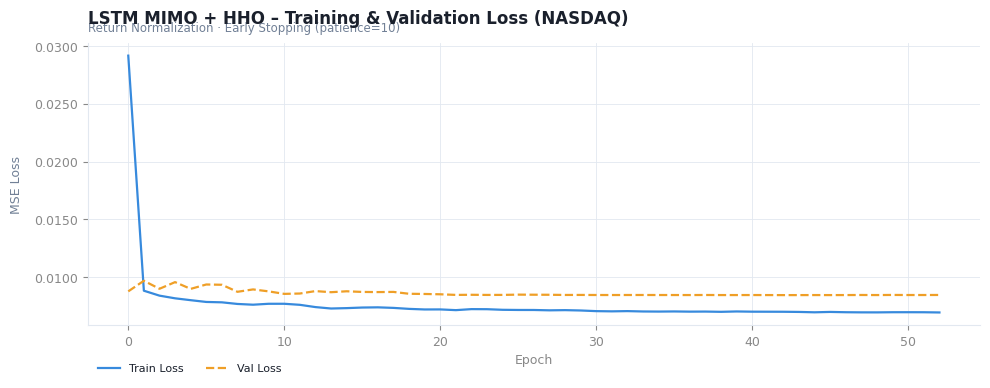

In [17]:
# ── Plot Loss ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.subplots_adjust(top=0.86, bottom=0.12, left=0.09, right=0.97)

ax.plot(history.history['loss'],     color=_C['loss_tr'], lw=1.6, label='Train Loss')
ax.plot(history.history['val_loss'], color=_C['loss_va'], lw=1.6, label='Val Loss', ls='--')

_spine(ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.4f}'))
ax.set_ylabel('MSE Loss', fontsize=9, color='#718096', labelpad=8)
ax.set_xlabel('Epoch', fontsize=9, color='#888888')
ax.set_title('LSTM MIMO + HHO – Training & Validation Loss (NASDAQ)',
             fontsize=12, fontweight='bold', color='#1A202C', loc='left', pad=14)
_subtitle(ax, 'Return Normalization · Early Stopping (patience=10)')

handles = [
    mlines.Line2D([], [], color=_C['loss_tr'], lw=1.6,          label='Train Loss'),
    mlines.Line2D([], [], color=_C['loss_va'], lw=1.6, ls='--', label='Val Loss'),
]
ax.legend(handles=handles, fontsize=8, frameon=False, ncol=2,
          loc='upper left', bbox_to_anchor=(0, -0.10))
plt.tight_layout(); plt.show()


## 18. PLOT – Aktual vs Prediksi


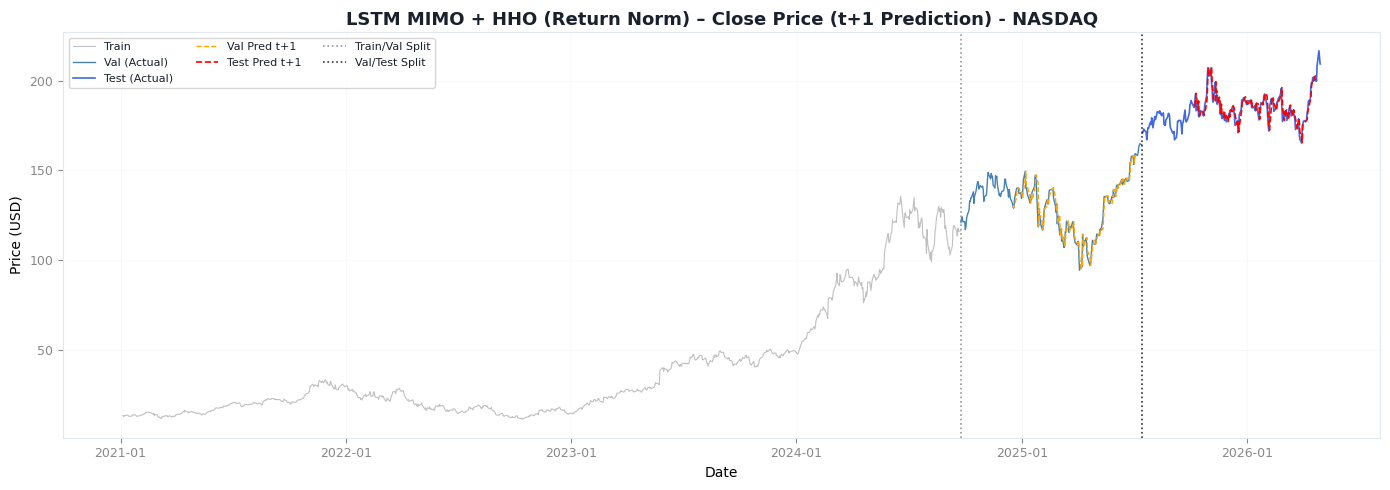

In [18]:
# ── Harga Close absolut per split (untuk plot) ───────────────────────────────
train_close_plot = close_abs.loc[train_ret.index]
val_close_plot   = close_abs.loc[val_ret.index]
test_close_plot  = close_abs.loc[test_ret.index]

# ── Plot 1: Keseluruhan t+1 ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_close_plot.index, train_close_plot,
        label='Train', color='silver', lw=0.8)
ax.plot(val_close_plot.index, val_close_plot,
        label='Val (Actual)', color='steelblue', lw=1.0)
ax.plot(test_close_plot.index, test_close_plot,
        label='Test (Actual)', color='royalblue', lw=1.2)
ax.plot(val_dates,  val_predict[:, 0],
        label='Val Pred t+1',  ls='--', color='orange', lw=1.0)
ax.plot(test_dates, test_predict[:, 0],
        label='Test Pred t+1', ls='--', color='red',    lw=1.2)
ax.axvline(val_ret.index[0],  color='gray',  lw=1.2, ls=':', alpha=0.8,
           label='Train/Val Split')
ax.axvline(test_ret.index[0], color='black', lw=1.2, ls=':', alpha=0.8,
           label='Val/Test Split')
ax.set_title('LSTM MIMO + HHO (Return Norm) – Close Price (t+1 Prediction) - NASDAQ',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)'); ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.3); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Date'); plt.tight_layout(); plt.show()

## 18b. PLOT – MIMO 5-Day Forecast (All Horizons)


1/1 [==============================] - 0s 11ms/step


C:\Users\ASUS\AppData\Local\Temp\ipykernel_15724\1412811944.py:76: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


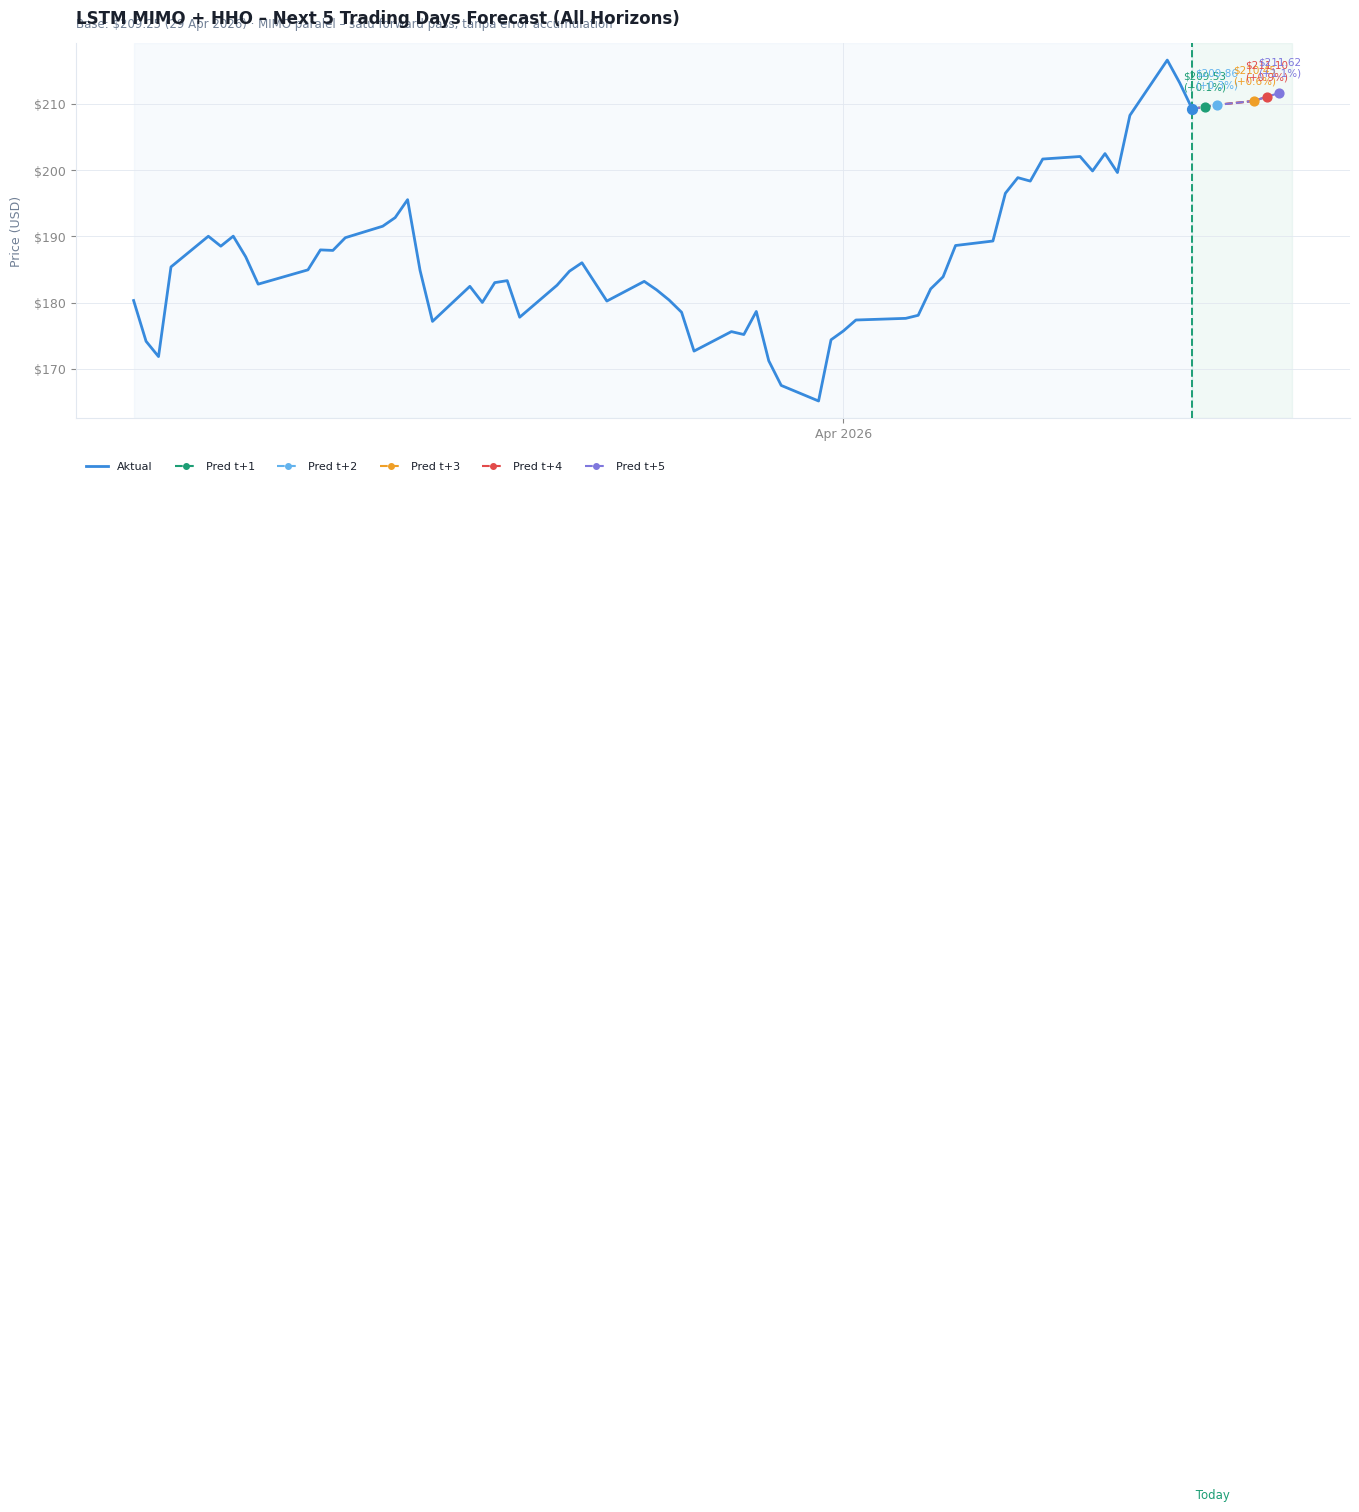

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 2 – MIMO 5-Day Forecast 
# Hanya prediksi terakhir (5 titik dari "today") – bukan sliding window
# ═══════════════════════════════════════════════════════════════════════════════

# ── Hitung prediksi dari window terakhir ─────────────────────────────────────
last_seq      = test_scaled[-n_input:].reshape(1, n_input, N_FEATURES)
last_pred_raw = best_model.predict(last_seq)
last_price    = float(close_abs.iloc[-1])
base_future   = np.array([last_price])
last_pred_inv = inverse_return_to_price(scaler, last_pred_raw, base_future, n_forecast)[0]

last_date    = data_ret.index[-1]
future_dates = pd.bdate_range(start=last_date, periods=n_forecast + 1)[1:]

# ── Data historis: 60 hari terakhir sebagai konteks ──────────────────────────
lookback   = 60
hist_dates = test_close_plot.index[-lookback:]
hist_close = test_close_plot.iloc[-lookback:].values

fig2, ax2 = plt.subplots(figsize=(14, 5))
fig2.subplots_adjust(top=0.88, bottom=0.13, left=0.07, right=0.98)

# Zona latar
ax2.axvspan(hist_dates[0], last_date,
            color=_C['act'],   alpha=0.04, zorder=0)
ax2.axvspan(last_date, future_dates[-1] + pd.tseries.offsets.BDay(1),
            color=_C['split'], alpha=0.06, zorder=0)

# Garis vertikal "Today"
ax2.axvline(x=last_date, color=_C['split'], lw=1.4, ls='--', zorder=3)
ylo, yhi = ax2.get_ylim()
ax2.text(last_date, yhi if yhi != 0 else hist_close.max() * 1.02,
         ' Today', color=_C['split'], fontsize=8.5, va='top', zorder=4)

# Harga historis aktual
ax2.plot(hist_dates, hist_close,
         color=_C['act'], lw=2.0, label='Aktual (60h terakhir)', zorder=5)
ax2.scatter([last_date], [last_price], color=_C['act'], s=50, zorder=6)

# 5 garis horizon – masing-masing dari today ke titik t+(i+1)
for i in range(n_forecast):
    x_line = [last_date] + list(future_dates[:i + 1])
    y_line = [last_price] + list(last_pred_inv[:i + 1])
    ax2.plot(x_line, y_line,
             ls='--', lw=1.5, color=HORIZON_COLORS[i],
             label=f'Pred t+{i+1}', zorder=4)
    ax2.scatter([future_dates[i]], [last_pred_inv[i]],
                color=HORIZON_COLORS[i], s=40, zorder=5)
    diff = last_pred_inv[i] - last_price
    sign = '+' if diff >= 0 else ''
    pct  = diff / last_price * 100
    ax2.annotate(
        f'${last_pred_inv[i]:.2f}\n({sign}{pct:.1f}%)',
        xy=(future_dates[i], last_pred_inv[i]),
        xytext=(0, 12), textcoords='offset points',
        ha='center', fontsize=7.5,
        color=HORIZON_COLORS[i], fontweight='500'
    )

_spine(ax2); _fmt_usd(ax2); _fmt_date(ax2)
ax2.set_ylabel('Price (USD)', fontsize=9, color='#718096', labelpad=8)
ax2.set_title(f'LSTM MIMO + HHO – Next {n_forecast} Trading Days Forecast (All Horizons)',
              fontsize=12, fontweight='bold', color='#1A202C', loc='left', pad=14)
_subtitle(ax2,
    f'Base: ${last_price:.2f} ({last_date.strftime("%d %b %Y")}) '
    '· MIMO paralel – satu forward pass, tanpa error accumulation')

handles2 = [mlines.Line2D([], [], color=_C['act'], lw=2.0, label='Aktual')]
for i in range(n_forecast):
    handles2.append(mlines.Line2D([], [], color=HORIZON_COLORS[i],
                                  lw=1.5, ls='--', marker='o',
                                  markersize=4, label=f'Pred t+{i+1}'))
ax2.legend(handles=handles2, fontsize=8, ncol=6, frameon=False,
           loc='upper left', bbox_to_anchor=(0, -0.09))
plt.tight_layout(); plt.show()


## 19. PLOT – Prediksi Masa Depan

1/1 [==============================] - 0s 14ms/step

  PREDIKSI 5 HARI KERJA KE DEPAN – LSTM MIMO + HHO
  Metode : Return Normalization | Walk-Forward | 6 Dim HHO
  Harga Close terakhir (base) : $209.25
  Date              Close (Pred)      Change
  ------------------------------------------
  2026-04-30              209.53    +0.28
  2026-05-01              209.86    +0.33
  2026-05-04              210.45    +0.59
  2026-05-05              211.10    +0.65
  2026-05-06              211.62    +0.52


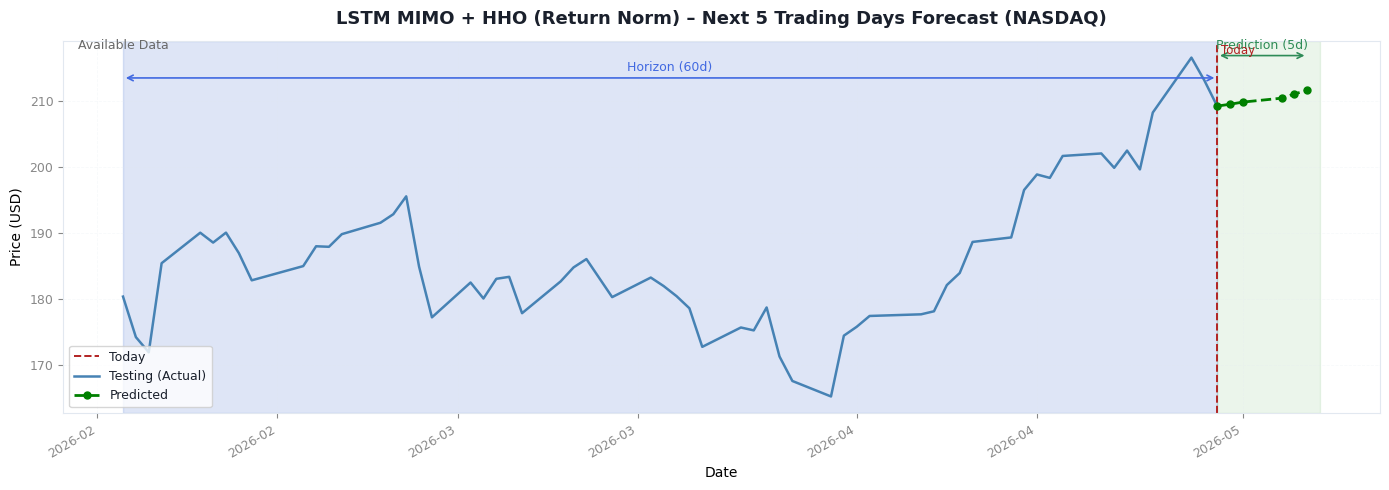

In [20]:
# ── Input: 60 hari return terakhir dari test set ─────────────────────────────
last_seq      = test_scaled[-n_input:].reshape(1, n_input, N_FEATURES)
last_pred_raw = best_model.predict(last_seq)

# ── Base price: harga Close terakhir yang tersedia ───────────────────────────
last_price    = float(close_abs.iloc[-1])
base_future   = np.array([last_price])
last_pred_inv = inverse_return_to_price(scaler, last_pred_raw, base_future, n_forecast)[0]

last_date    = data_ret.index[-1]
future_dates = pd.bdate_range(start=last_date, periods=n_forecast + 1)[1:]

print("\n" + "="*60)
print(f"  PREDIKSI {n_forecast} HARI KERJA KE DEPAN – LSTM MIMO + HHO")
print(f"  Metode : Return Normalization | Walk-Forward | 6 Dim HHO")
print("="*60)
print(f"  Harga Close terakhir (base) : ${last_price:.2f}")
print(f"  {'Date':<14}  {'Close (Pred)':>14}  {'Change':>10}")
print(f"  {'-'*42}")
prev = last_price
for i in range(n_forecast):
    chg = last_pred_inv[i] - prev
    print(f"  {str(future_dates[i].date()):<14}  {last_pred_inv[i]:>14.2f}  "
          f"  {'+' if chg>=0 else ''}{chg:.2f}")
    prev = last_pred_inv[i]

# ── Visualisasi ───────────────────────────────────────────────────────────────
lookback      = 60
hist_dates    = test_close_plot.index[-lookback:]
hist_close    = test_close_plot.iloc[-lookback:].values
today         = last_date
horizon_start = hist_dates[-n_input]

fig, ax = plt.subplots(figsize=(14, 5))

ax.axvspan(hist_dates[0], today,   alpha=0.06, color='steelblue')
ax.axvspan(horizon_start, today,   alpha=0.12, color='royalblue')
ax.axvspan(today, future_dates[-1] + pd.tseries.offsets.BDay(1),
           alpha=0.08, color='green')

ax.axvline(x=today, color='firebrick', lw=1.4, ls='--', label='Today')

ax.plot(hist_dates, hist_close,
        color='steelblue', lw=1.8, label='Testing (Actual)')

connect_dates = [last_date] + list(future_dates)
connect_vals  = [hist_close[-1]] + list(last_pred_inv)
ax.plot(connect_dates, connect_vals,
        color='green', lw=2, ls='--', marker='o', markersize=5, label='Predicted')

ax.set_title(
    f'LSTM MIMO + HHO (Return Norm) – Next {n_forecast} Trading Days Forecast (NASDAQ)',
    fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Price (USD)', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.legend(fontsize=9, loc='lower left')
ax.grid(alpha=0.25, ls='--')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)

y_bot, y_top = ax.get_ylim()
y_range      = y_top - y_bot

def mid_num(d1, d2):
    return (mdates.date2num(d1) + mdates.date2num(d2)) / 2

y_arr1 = y_top - y_range * 0.04
y_arr2 = y_top - y_range * 0.10

ax.annotate('', xy=(horizon_start, y_arr1), xytext=(hist_dates[0], y_arr1),
            arrowprops=dict(arrowstyle='<->', color='dimgray', lw=1.2))
ax.text(mid_num(hist_dates[0], horizon_start), y_arr1 + y_range * 0.01,
        'Available Data', ha='center', va='bottom',
        fontsize=9, color='dimgray', transform=ax.transData)

ax.annotate('', xy=(today, y_arr2), xytext=(horizon_start, y_arr2),
            arrowprops=dict(arrowstyle='<->', color='royalblue', lw=1.2))
ax.text(mid_num(horizon_start, today), y_arr2 + y_range * 0.01,
        f'Horizon ({n_input}d)', ha='center', va='bottom',
        fontsize=9, color='royalblue', transform=ax.transData)

ax.annotate('', xy=(future_dates[-1], y_arr1), xytext=(today, y_arr1),
            arrowprops=dict(arrowstyle='<->', color='seagreen', lw=1.2))
ax.text(mid_num(today, future_dates[-1]), y_arr1 + y_range * 0.01,
        f'Prediction ({n_forecast}d)', ha='center', va='bottom',
        fontsize=9, color='seagreen', transform=ax.transData)

ax.text(mdates.date2num(today) + 0.3, y_top - y_range * 0.01,
        'Today', va='top', ha='left',
        fontsize=8.5, color='firebrick', transform=ax.transData)

plt.tight_layout(); plt.show()


## 20. PLOT – HHO Convergence

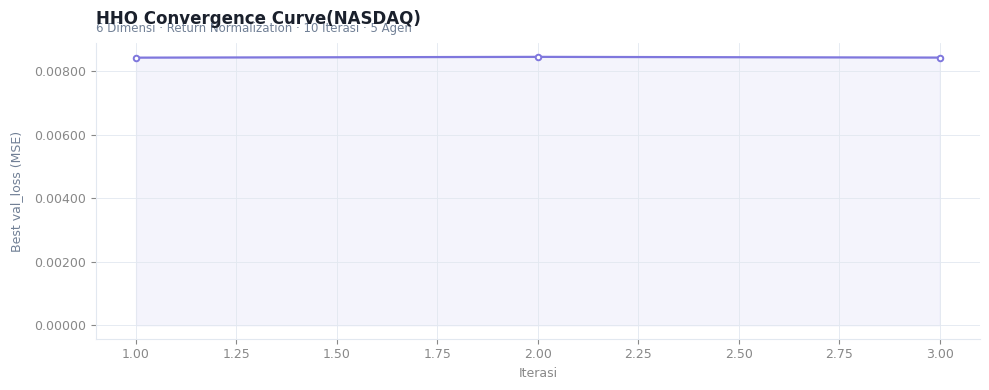

In [21]:
fig4, ax4 = plt.subplots(figsize=(10, 4))
fig4.subplots_adjust(top=0.86, bottom=0.12, left=0.10, right=0.97)

iters = range(1, len(best_convergence) + 1)
ax4.plot(iters, best_convergence,
         color=_C['hho_cv'], lw=1.6, marker='o', markersize=4,
         markerfacecolor='white', markeredgecolor=_C['hho_cv'], markeredgewidth=1.4)
ax4.fill_between(iters, best_convergence, alpha=0.08, color=_C['hho_cv'])

_spine(ax4)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.5f}'))
ax4.set_ylabel('Best val_loss (MSE)', fontsize=9, color='#718096', labelpad=8)
ax4.set_xlabel('Iterasi', fontsize=9, color='#888888')
ax4.set_title('HHO Convergence Curve(NASDAQ)',
              fontsize=12, fontweight='bold', color='#1A202C', loc='left', pad=14)
_subtitle(ax4, f'6 Dimensi · Return Normalization · {Max_iter} Iterasi · {SearchAgents_no} Agen')
plt.tight_layout(); plt.show()


## 21. PLOT – HHO Operations per Run

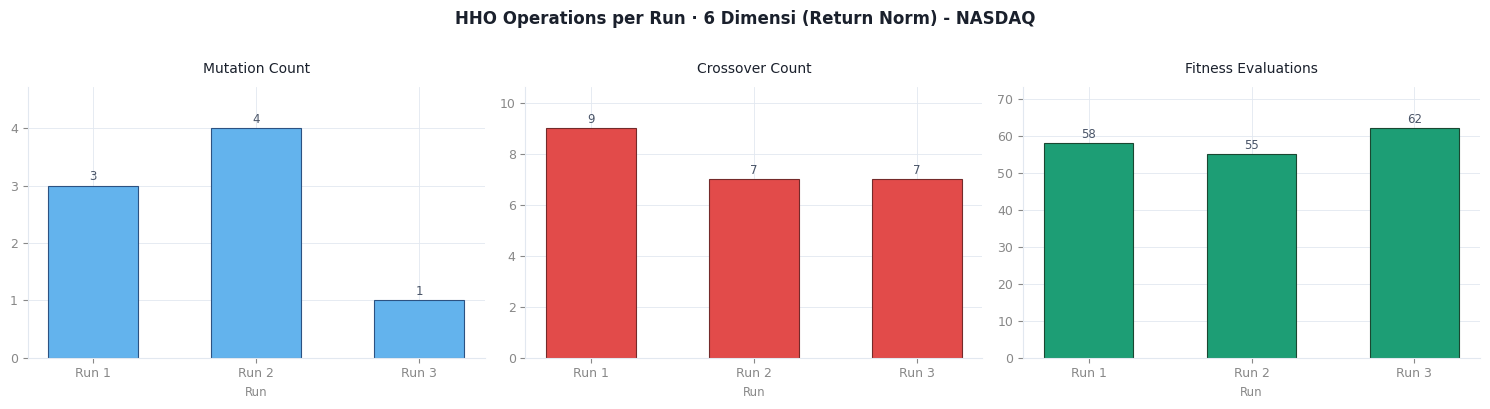

In [22]:
runs_x = list(range(1, num_runs + 1))
fig5, axes5 = plt.subplots(1, 3, figsize=(15, 4))
fig5.subplots_adjust(top=0.84, bottom=0.12, left=0.06, right=0.98, wspace=0.32)

bar_cfg = [
    (mutation_counts,     _C['val_act'], '#2C5282', 'Mutation Count'),
    (crossover_counts,    _C['test_p'],  '#742A2A', 'Crossover Count'),
    (fitness_evaluations, _C['split'],   '#1A4731', 'Fitness Evaluations'),
]
for ax_i, (vals, fc, ec, ttl) in zip(axes5, bar_cfg):
    bars = ax_i.bar(runs_x, vals, color=fc, edgecolor=ec,
                    linewidth=0.8, width=0.55, zorder=2)
    for bar, val in zip(bars, vals):
        ax_i.text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + max(vals) * 0.01,
                  str(int(val)), ha='center', va='bottom',
                  fontsize=8.5, color='#4A5568', fontweight='500')
    _spine(ax_i)
    ax_i.set_title(ttl, fontsize=10, fontweight='500', color='#1A202C', pad=10)
    ax_i.set_xlabel('Run', fontsize=8.5, color='#888888')
    ax_i.set_xticks(runs_x)
    ax_i.set_xticklabels([f'Run {r}' for r in runs_x])
    ax_i.set_ylim(0, max(vals) * 1.18)

fig5.suptitle('HHO Operations per Run · 6 Dimensi (Return Norm) - NASDAQ',
              fontsize=12, fontweight='bold', color='#1A202C', y=1.01)
plt.tight_layout(); plt.show()


## 22. PLOT – Distribution of Fitness Values

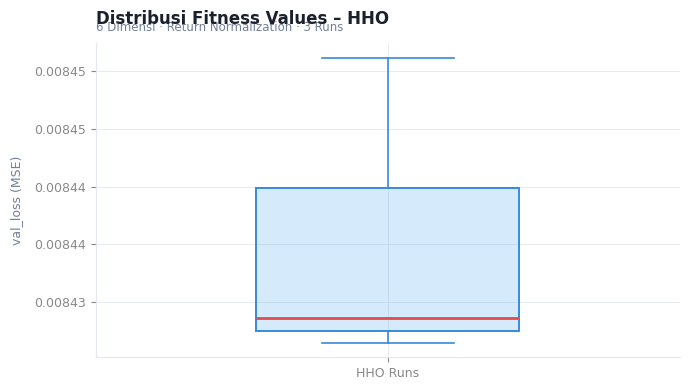

In [23]:
fig6, ax6 = plt.subplots(figsize=(7, 4))
fig6.subplots_adjust(top=0.86, bottom=0.12, left=0.14, right=0.97)

ax6.boxplot(fitness_values, patch_artist=True, widths=0.45,
            boxprops=dict(facecolor=_C['val_act'] + '44',
                          color=_C['act'], linewidth=1.4),
            medianprops=dict(color=_C['test_p'], linewidth=2),
            whiskerprops=dict(color=_C['act'], linewidth=1.2),
            capprops=dict(color=_C['act'], linewidth=1.2),
            flierprops=dict(marker='o', color=_C['test_p'],
                            markerfacecolor=_C['test_p'], markersize=5))

_spine(ax6)
ax6.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.5f}'))
ax6.set_ylabel('val_loss (MSE)', fontsize=9, color='#718096', labelpad=8)
ax6.set_xticks([1]); ax6.set_xticklabels(['HHO Runs'])
ax6.set_title('Distribusi Fitness Values – HHO',
              fontsize=12, fontweight='bold', color='#1A202C', loc='left', pad=14)
_subtitle(ax6, f'6 Dimensi · Return Normalization · {num_runs} Runs')
plt.tight_layout(); plt.show()


## 23. TABEL RINGKASAN EVALUASI

In [24]:
print("\n" + "="*75)
print("  RINGKASAN EVALUASI – LSTM MIMO + HHO 6 Dim (Return Normalization)")
print("="*75)
print(f"  {'Set':<8} {'Horizon':<14} {'RMSE':>10} {'MAE':>10} {'MAPE':>10}")
print(f"  {'-'*54}")

for label, y_true_abs, y_pred_abs in [
    ("TRAIN", y_train_abs, train_predict),
    ("VAL",   y_val_abs,   val_predict),
    ("TEST",  y_test_abs,  test_predict),
]:
    for i in range(n_forecast):
        _, rmse, mae, mape = evaluate(y_true_abs[:, i], y_pred_abs[:, i])
        h = f"t+{i+1} (Hari ke-{i+1})"
        print(f"  {label:<8} {h:<14} {rmse:>10.4f} {mae:>10.4f} {mape:>9.2f}%")
    _, rmse_a, mae_a, mape_a = evaluate(
        y_true_abs.flatten(), y_pred_abs.flatten())
    print(f"  {label:<8} {'Average':<14} {rmse_a:>10.4f} {mae_a:>10.4f} {mape_a:>9.2f}%")
    print(f"  {'-'*54}")



  RINGKASAN EVALUASI – LSTM MIMO + HHO 6 Dim (Return Normalization)
  Set      Horizon              RMSE        MAE       MAPE
  ------------------------------------------------------
  TRAIN    t+1 (Hari ke-1)     1.8154     1.0280      2.52%
  TRAIN    t+2 (Hari ke-2)     2.4328     1.4573      3.66%
  TRAIN    t+3 (Hari ke-3)     3.0210     1.7852      4.43%
  TRAIN    t+4 (Hari ke-4)     3.4718     2.0700      5.11%
  TRAIN    t+5 (Hari ke-5)     3.9317     2.3555      5.73%
  TRAIN    Average            3.0283     1.7392      4.29%
  ------------------------------------------------------
  VAL      t+1 (Hari ke-1)     4.6444     3.2813      2.66%
  VAL      t+2 (Hari ke-2)     6.1609     4.6134      3.75%
  VAL      t+3 (Hari ke-3)     7.8110     5.8539      4.77%
  VAL      t+4 (Hari ke-4)     8.7654     6.8826      5.62%
  VAL      t+5 (Hari ke-5)     9.5317     7.6274      6.22%
  VAL      Average            7.5924     5.6517      4.60%
  --------------------------------------

## 24. SIMPAN MODEL & METADATA

In [25]:
import json, os

os.makedirs('models', exist_ok=True)
best_model.save('models/lstm_mimo_hho_yfinance.h5')

metadata = {
    "model_name": "LSTM MIMO + HHO",
    "n_input": n_input,
    "n_forecast": n_forecast,
    "features": TARGET_COLS,
    "hyperparameters": {
        "units_1": best_units1,
        "units_2": best_units2,
        "dropout_rate_1": best_drop1,
        "dropout_rate_2": best_drop2,
        "learning_rate": best_lr,
        "batch_size": best_bs
    },
    "hho_search": {
        "dimensions": dim,
        "lower_bound": lb.tolist(),
        "upper_bound": ub.tolist(),
        "search_agents": SearchAgents_no,
        "max_iter": Max_iter,
        "num_runs": num_runs,
        "best_val_loss": float(best_overall_fitness)
    },
    "normalization": "MinMaxScaler pada percentage change (return) per-fitur, fit pada train only",
    "split": "70/15/15 (walk-forward, time-ordered)"
}
with open('models/lstm_mimo_hho_yfinance_meta.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model dan metadata LSTM MIMO + HHO tersimpan di folder 'models/'.")

Model dan metadata LSTM MIMO + HHO tersimpan di folder 'models/'.
